In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7" "scikit-learn>=1.3" "pymc==6.3.2" "arviz==1.3.0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pymc as pm
import arviz as az
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150      # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True                            # 여백은 tight_layout 이 알아서
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     # 위 테두리·오른쪽 테두리·격자를 걷어내 데이터만 남긴다
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림들이 함께 쓰는 색 — 구간=하늘색, 무 풀링 점=회색, 기준선=남색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3", "참값": "#757575"}
FIG_W = 10.0     # 캔버스 폭은 모두 이 값으로 고정하고 높이만 그림마다 조절한다

print("사용 폰트:", FONT, "| PyMC", pm.__version__, "· ArviZ", az.__version__,
      "| 채점 셀은 LMS 가 자동으로 준비합니다")

g++ not available, if using conda: `conda install gxx`


사용 폰트: DejaVu Sans | PyMC 6.3.2 · ArviZ 1.3.0 | 채점 셀은 LMS 가 자동으로 준비합니다


In [2]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 변수를 직접 만듭니다
from sklearn.datasets import fetch_openml

# freMTPL2freq — 프랑스 자동차보험 계약별 사고 기록 (678,013 x 12). OpenML 에서 바로 내려받습니다
df = fetch_openml(data_id=41214, as_frame=True).frame
df["IDpol"] = df["IDpol"].astype(int)
for c in ["Area", "VehBrand", "VehGas", "Region"]:
    df[c] = df[c].astype(str).str.strip("'").astype("category")

# 첫날 고정한 전처리 2개 규칙 — 5일 내내 이대로 씁니다
df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)   # 사고 5건 이상은 극소수라 상한 4 로 상한 처리
df["Exposure"] = df["Exposure"].clip(upper=1.0)           # 유지 기간은 1년 상한

# 지역 x 브랜드 242개 세그먼트 — 오늘 앞 두 미션이 쓰는 세그먼트이고, 여기서 다루는 값은 연간 사고율입니다
SEGS242 = (df.groupby(["Region", "VehBrand"], observed=True)
              .agg(n=("IDpol", "size"), claims=("ClaimNb", "sum"), expo=("Exposure", "sum"))
              .reset_index().sort_values(["Region", "VehBrand"]).reset_index(drop=True))

CLAIMS = SEGS242["claims"].to_numpy(dtype=float)    # 쓸 변수 1 — 세그먼트별 사고 건수 (단위 건)
EXPO = SEGS242["expo"].to_numpy(dtype=float)        # 쓸 변수 2 — 세그먼트별 노출 (단위 년)
RAW = CLAIMS / EXPO                                  # 쓸 변수 3 — 세그먼트별 무 풀링 값 (건/년)
LAM_POOL = float(CLAIMS.sum() / EXPO.sum())          # 쓸 변수 4 — 완전 풀링 값 하나 (건/년)
J = int(len(CLAIMS))                                 # 쓸 변수 5 — 세그먼트 수
I662 = int(np.argmin(np.abs(EXPO - 6.62)))           # 쓸 변수 6 — 노출 6.62년 세그먼트의 번호
THIN12 = np.argsort(EXPO)[:12]                       # 쓸 변수 7 — 노출이 적은 12개 세그먼트의 번호

print(f"계약 {len(df):,} 건 · 노출 합 {df['Exposure'].sum():,.2f} 년 · 사고 합 {int(df['ClaimNb'].sum()):,} 건")
print(f"세그먼트 {J} 개 · 세그먼트의 계약 수 최소 {SEGS242['n'].min():,} / 중앙 {SEGS242['n'].median():,.0f}"
      f" / 최대 {SEGS242['n'].max():,} 건 · 사고가 한 건도 없는 세그먼트 {int((CLAIMS == 0).sum())} 개")
print(f"완전 풀링 {LAM_POOL:.6f} 건/년 · 노출 6.62년 세그먼트의 무 풀링 {RAW[I662]:.4f} 건/년"
      f" · 노출이 가장 많은 세그먼트({EXPO.max():,.0f} 년)의 무 풀링 {RAW[int(EXPO.argmax())]:.4f} 건/년")
print("쓸 수 있는 이름 : CLAIMS (세그먼트별 사고 건수, 건) · EXPO (세그먼트별 노출, 년) · RAW (무 풀링, 건/년)"
      " · LAM_POOL (완전 풀링, 건/년) · J (세그먼트 수) · I662 (노출 6.62년 세그먼트 번호) · THIN12 (관측이 적은 12개 세그먼트 번호)")

계약 678,013 건 · 노출 합 358,360.11 년 · 사고 합 36,056 건
세그먼트 242 개 · 세그먼트의 계약 수 최소 6 / 중앙 720 / 최대 54,103 건 · 사고가 한 건도 없는 세그먼트 9 개
완전 풀링 0.100614 건/년 · 노출 6.62년 세그먼트의 무 풀링 0.3021 건/년 · 노출이 가장 많은 세그먼트(35,949 년)의 무 풀링 0.0890 건/년
쓸 수 있는 이름 : CLAIMS (세그먼트별 사고 건수, 건) · EXPO (세그먼트별 노출, 년) · RAW (무 풀링, 건/년) · LAM_POOL (완전 풀링, 건/년) · J (세그먼트 수) · I662 (노출 6.62년 세그먼트 번호) · THIN12 (관측이 적은 12개 세그먼트 번호)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, log_lam]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.


1) 노출 6.62년 세그먼트의 부분 풀링 값: 0.1039 건/년
2) 구간이 완전 풀링 값을 포함한 세그먼트 수 (개): 12
3) 대조용
RAW[I662]: 0.3021148036253776
LAM_POOL: 0.10061387819220949


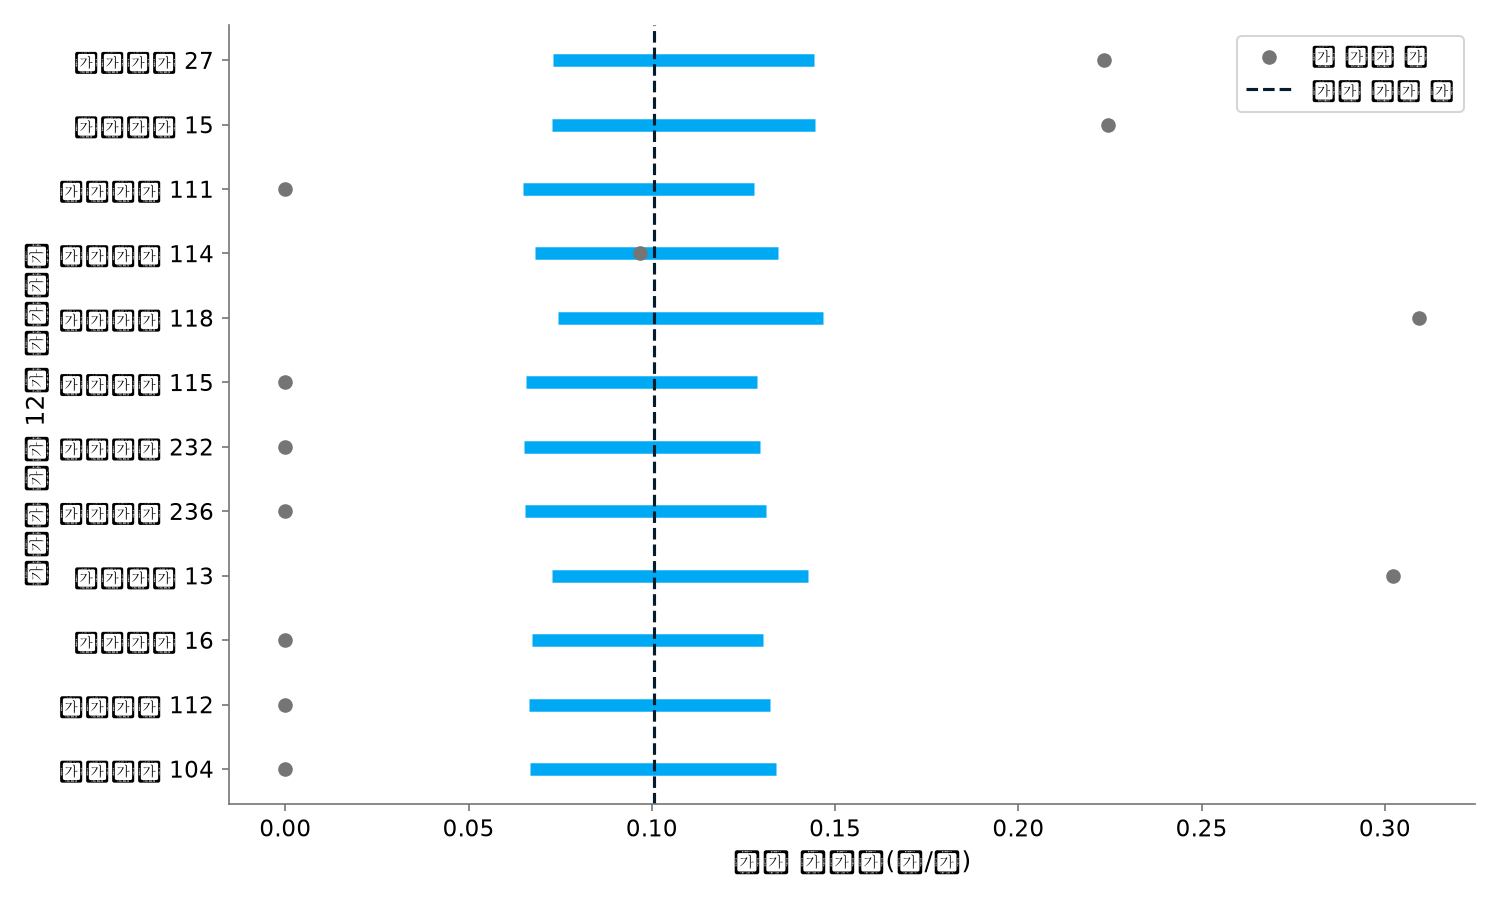

In [5]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
아래 변수는 그대로 사용해
CLAIMS: 세그먼트별 사고 건수, 단귀 건
EXPO: 세그먼트별 노출
RAW: 세그먼트별 무 풀링 값
LAM_POOL: 완전 풀링 값
J: 세그먼트 수 242
I662: 노출 6.62냔 세그먼트의 번호
THIN12: 노출이 적은 12개 세그먼트 번호

1. 노출 6.62년 세그먼트의 부분 풀링 값: 단위 건/년, 소수점 아래 4자리
2. 구간이 완전 풀링 값을 포함한 세그먼트의 수
3. 대조용 2행 RAW[I662], LAM_POOL을 서로 다른 행에 출력
4. 그래프(막대)
가로막대: 세그먼트마다 90% 신용구간 하나씩, 총 12개
점: 같은 세그먼트의 RAW값 하나씩, 총 12개
세로선: LAM_POOL 값 위치에 그림을 위아래로 가로지르는 선 하나
가로축이름: 연간 사고율(건/년)
세로축 이름: 노출이 적은 12개 세그먼트

체인 4개 · 반복 1,000회 · 워밍업 1,000회 · 시드 49 로 고정
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm

with pm.Model() as model:
    mu = pm.Normal("mu", mu=np.log(LAM_POOL), sigma=2)
    sigma = pm.HalfNormal("sigma", sigma=1)
    log_lam = pm.Normal("log_lam", mu=mu, sigma=sigma, shape=J)
    pm.Poisson("obs", mu=EXPO * pm.math.exp(log_lam), observed=CLAIMS)
    idata = pm.sample(1000, tune=1000, chains=4, random_seed=49, progressbar=False)

log_lam_samples = idata.posterior["log_lam"].values.reshape(-1, J)
lam_samples = np.exp(log_lam_samples)

partial_662 = lam_samples[:, I662].mean()
print(f"1) 노출 6.62년 세그먼트의 부분 풀링 값: {partial_662:.4f} 건/년")

lo = np.quantile(lam_samples[:, THIN12], 0.05, axis=0)
hi = np.quantile(lam_samples[:, THIN12], 0.95, axis=0)
contains = int(((lo <= LAM_POOL) & (LAM_POOL <= hi)).sum())
print(f"2) 구간이 완전 풀링 값을 포함한 세그먼트 수 (개): {contains}")

print("3) 대조용")
print("RAW[I662]:", RAW[I662])
print("LAM_POOL:", LAM_POOL)

means = lam_samples[:, THIN12].mean(axis=0)
raw_vals = RAW[THIN12]

fig, ax = plt.subplots(figsize=(FIG_W, 6))
y = np.arange(len(THIN12))
err = np.vstack([means - lo, hi - means])
ax.errorbar(means, y, xerr=err, fmt="none", ecolor=COL["하늘색"], elinewidth=6, capsize=0)
ax.scatter(raw_vals, y, color=COL["회색"], zorder=3, label="무 풀링 값")
ax.axvline(LAM_POOL, color=COL["남색"], linestyle="--", label="완전 풀링 값")
ax.set_yticks(y)
ax.set_yticklabels([f"세그먼트 {j}" for j in THIN12])
ax.set_xlabel("연간 사고율(건/년)")
ax.set_ylabel("노출이 적은 12개 세그먼트")
ax.legend()
plt.show()

In [6]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 변수를 직접 만듭니다
if "CLAIMS" not in globals():                                   # 이 미션만 따로 열어도 이 셀부터 실행하면 됩니다
    from sklearn.datasets import fetch_openml                    # (미션 1 을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)       # 첫날 고정한 전처리 2개 규칙 — 미션 1 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)
    SEGS242 = (df.groupby(["Region", "VehBrand"], observed=True)
                  .agg(n=("IDpol", "size"), claims=("ClaimNb", "sum"), expo=("Exposure", "sum"))
                  .reset_index().sort_values(["Region", "VehBrand"]).reset_index(drop=True))
    CLAIMS = SEGS242["claims"].to_numpy(dtype=float)   # 쓸 변수 1 — 세그먼트별 사고 건수 (단위 건)
    EXPO = SEGS242["expo"].to_numpy(dtype=float)       # 쓸 변수 2 — 세그먼트별 노출 (단위 년)
    J = int(len(CLAIMS))                                # 쓸 변수 3 — 세그먼트 수
    I662 = int(np.argmin(np.abs(EXPO - 6.62)))          # 쓸 변수 4 — 노출 6.62년 세그먼트의 번호

THRESH_RHAT = 1.01    # 쓸 변수 5 — 이론에서 정한 R-hat 기준값
THRESH_ESS = 400      # 쓸 변수 6 — 이론에서 정한 유효표본수 기준값 (단위 개)

print(f"세그먼트 {J} 개 · 미션 1 과 같은 모형을 같은 기록에 다시 적용합니다 — 바뀌는 것은 표집기를 호출하는 코드 행뿐입니다")
print(f"진단값은 모수마다 따로 나옵니다 — 공통 평균 하나 · 세그먼트 간 표준편차 하나 · 세그먼트마다 하나씩 {J} 개")
print(f"이론에서 정한 기준값 2개 — R-hat 은 {THRESH_RHAT} 이하 · 유효표본수는 {THRESH_ESS} 개 이상")
print("쓸 수 있는 이름 : CLAIMS (세그먼트별 사고 건수, 건) · EXPO (세그먼트별 노출, 년) · J (세그먼트 수)"
      " · I662 (노출 6.62년 세그먼트 번호) · THRESH_RHAT (R-hat 기준값) · THRESH_ESS (유효표본수 기준값, 개)")

세그먼트 242 개 · 미션 1 과 같은 모형을 같은 기록에 다시 적용합니다 — 바뀌는 것은 표집기를 호출하는 코드 행뿐입니다
진단값은 모수마다 따로 나옵니다 — 공통 평균 하나 · 세그먼트 간 표준편차 하나 · 세그먼트마다 하나씩 242 개
이론에서 정한 기준값 2개 — R-hat 은 1.01 이하 · 유효표본수는 400 개 이상
쓸 수 있는 이름 : CLAIMS (세그먼트별 사고 건수, 건) · EXPO (세그먼트별 노출, 년) · J (세그먼트 수) · I662 (노출 6.62년 세그먼트 번호) · THRESH_RHAT (R-hat 기준값) · THRESH_ESS (유효표본수 기준값, 개)


In [7]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다. 아래는 전임 담당자가 남긴 코드로, 돌아가고 값도 그럴듯하지만 그 값을 신뢰할 수 있는지는 확인하지 않았습니다.
# 이 코드는 그대로 두고 그 아래에 무엇을 더 실행할지 PROMPT 에 적으면 도우미가 이어서 작성합니다.
PROMPT = """

"""
# --- 여기부터 AI 코드 ---
# ↓ 전임 담당자의 코드 (그대로 둡니다) — PROMPT 를 채우고 실행하면 무엇이 빠졌는지 채점이 짚어 줍니다
with pm.Model() as m_prev:
    mu = pm.Normal("mu", np.log(0.10), 1.0)
    tau = pm.HalfNormal("tau", 1.0)
    z = pm.Normal("z", 0.0, 1.0, shape=J)
    theta = pm.Deterministic("theta", tau * z)
    pm.Poisson("obs", mu=pm.math.exp(mu + theta) * EXPO, observed=CLAIMS)
    prev = pm.sample(draws=1000, tune=1000, chains=4,
                     step=pm.Metropolis(),          # NUTS 가 느려서 이걸로 바꿔 뒀습니다
                     random_seed=49, progressbar=False)

s = az.summary(prev, var_names=["mu", "tau"])
print(s[["mean", "r_hat", "ess_bulk"]])
lam_prev = np.exp(prev.posterior["mu"].values[..., None]
                  + prev.posterior["theta"].values).reshape(-1, J)
print(f"노출 6.62년 세그먼트 사후평균 = {lam_prev[:, I662].mean():.4f} 건/년")
print("표집 완료 — 이 값을 요율표에 사용합니다")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [tau]
>Metropolis: [z]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 44 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


       mean r_hat ess_bulk
mu   -2.343  1.09       41
tau   0.208  1.10       34
노출 6.62년 세그먼트 사후평균 = 0.1041 건/년
표집 완료 — 이 값을 요율표에 사용합니다


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, tau, z]
Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 33 seconds.


1) 수정 후 가장 큰 R-hat: 1.0012
2) 수정 후 가장 작은 유효표본수 (개): 7044
3) 대조용 — mu 사후평균: -2.3456 · exp(mu) 연간 사고율: 0.0958 건/년


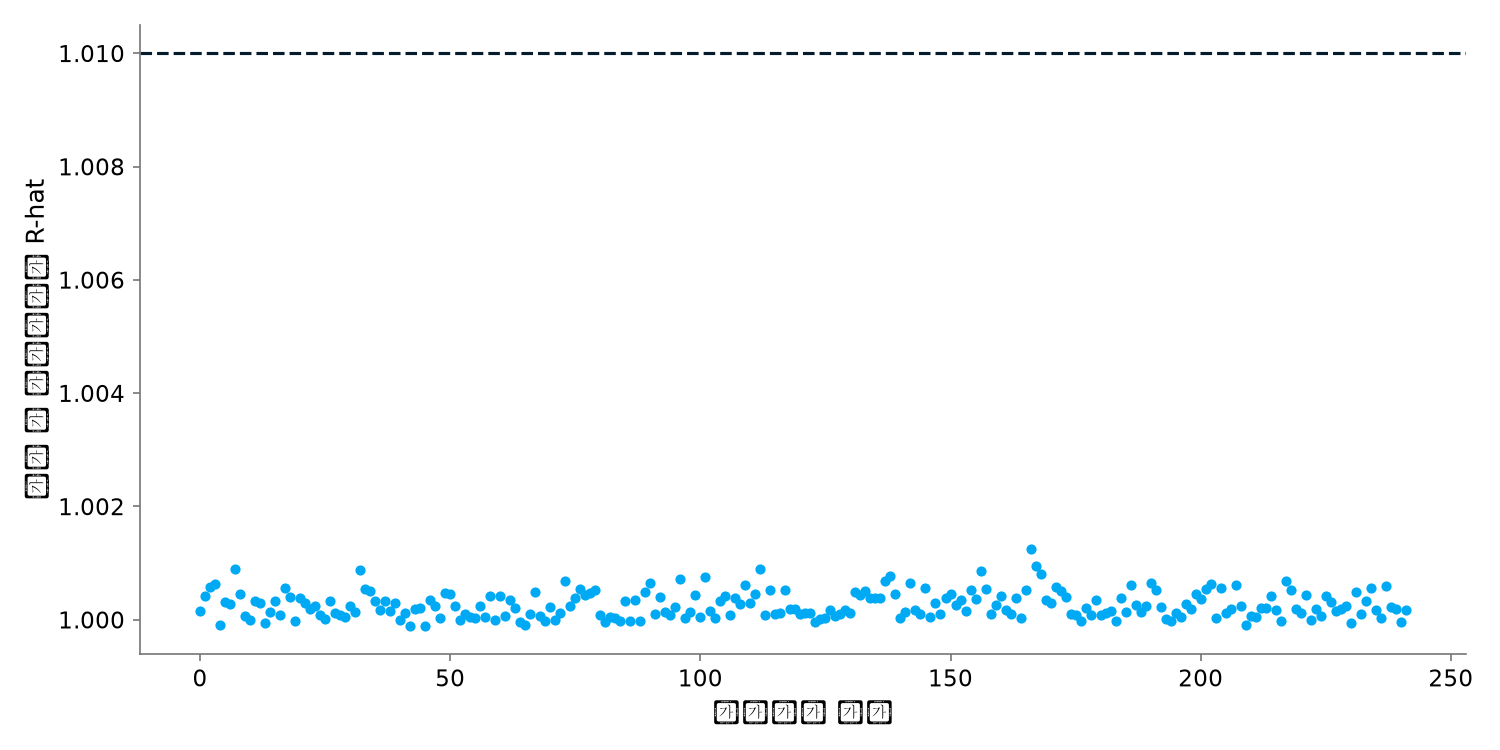

In [9]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다. 아래는 전임 담당자가 남긴 코드로, 돌아가고 값도 그럴듯하지만 그 값을 신뢰할 수 있는지는 확인하지 않았습니다.
# 이 코드는 그대로 두고 그 아래에 무엇을 더 실행할지 PROMPT 에 적으면 도우미가 이어서 작성합니다.
PROMPT = """
1. 수정 후 가장 큰 R-hat: 소수점 아래 4자리 (체인 4개 · 반복 5,000회 · 워밍업 5,000회 · 시드 49)
2. 수정 후 가장 작은 유효표본수: 단위 개, 정수
3. 대조용 한 행: 같은 표본에서 공통 평균 mu의 사후평균과 그 값을 지수로 복원한 연간 사고율 한행
4. 그래프
점: 세그먼트 하나에 점 하나 총 242개
가로선: 기준값 1.01 위치에 그림을 좌우로 가로지르는 선 하나
가로축: 세그먼트 번호
세로축: 고친 뒤 세그먼트별 R-hat
"""
# --- 여기부터 AI 코드 ---
with pm.Model() as m_fix:
    mu = pm.Normal("mu", np.log(0.10), 1.0)
    tau = pm.HalfNormal("tau", 1.0)
    z = pm.Normal("z", 0.0, 1.0, shape=J)
    theta = pm.Deterministic("theta", tau * z)
    pm.Poisson("obs", mu=pm.math.exp(mu + theta) * EXPO, observed=CLAIMS)
    fix = pm.sample(draws=5000, tune=5000, chains=4,
                     random_seed=49, progressbar=False)

s_theta = az.summary(fix, var_names=["theta"])
s_mu = az.summary(fix, var_names=["mu"])

max_rhat = s_theta["r_hat"].max()
min_ess = int(s_theta["ess_bulk"].min())

print(f"1) 수정 후 가장 큰 R-hat: {max_rhat:.4f}")
print(f"2) 수정 후 가장 작은 유효표본수 (개): {min_ess}")

mu_mean = s_mu.loc["mu", "mean"]
print(f"3) 대조용 — mu 사후평균: {mu_mean:.4f} · exp(mu) 연간 사고율: {np.exp(mu_mean):.4f} 건/년")

rhats = s_theta["r_hat"].values
fig, ax = plt.subplots(figsize=(FIG_W, 5))
ax.scatter(np.arange(J), rhats, color=COL["하늘색"], s=15)
ax.axhline(THRESH_RHAT, color=COL["남색"], linestyle="--")
ax.set_xlabel("세그먼트 번호")
ax.set_ylabel("고친 뒤 세그먼트별 R-hat")
plt.show()

In [10]:
# 미션 3 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 3 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 이 미션만 따로 열어도 이 셀부터 실행하면 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)       # 첫날 고정한 전처리 2개 규칙 — 앞 미션과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)

# 다루는 값이 바뀝니다 — 사고를 몇 번 겪었는가가 아니라 「1번 이상 겪었는가」 로 계약 하나를 0 아니면 1 로 봅니다
df["사고겪음"] = (df["ClaimNb"] > 0).astype(int)

# 지역 x 브랜드 x 차량 출력 등급 2,323개 세그먼트 — 앞 두 미션의 242개 세그먼트를 출력 등급으로 한 번 더 나눈 세그먼트입니다
SEGS2323 = (df.groupby(["Region", "VehBrand", "VehPower"], observed=True)
               .agg(n=("IDpol", "size"), k=("사고겪음", "sum"))
               .reset_index().sort_values(["Region", "VehBrand", "VehPower"]).reset_index(drop=True))

N23 = SEGS2323["n"].to_numpy(dtype=float)     # 쓸 변수 1 — 세그먼트별 계약 수 (단위 건)
K23 = SEGS2323["k"].to_numpy(dtype=float)     # 쓸 변수 2 — 세그먼트별 사고를 겪은 계약 수 (단위 건)
RAW23 = K23 / N23                              # 쓸 변수 3 — 세그먼트별 무 풀링 값 (비율)
P_POOL = float(K23.sum() / N23.sum())          # 쓸 변수 4 — 완전 풀링 값 하나 (비율)
J23 = int(len(N23))                            # 쓸 변수 5 — 세그먼트 수
I63 = int(SEGS2323.index[(SEGS2323["n"] == 63) & (SEGS2323["k"] == 4)][0])   # 쓸 변수 6 — 계약 63건·사고 4건 세그먼트의 번호

# 첫날 이 세그먼트에 적용한 구간 — 무 풀링 비율에 ±2 표준오차를 붙인 구간입니다 (공식으로 바로 구하는 해(closed-form)라 여기서 다시 계산합니다)
SE63 = float(np.sqrt(RAW23[I63] * (1 - RAW23[I63]) / N23[I63]))   # 쓸 변수 7 — 그 세그먼트의 표준오차
LO_D45 = float(RAW23[I63] - 2 * SE63)                             # 쓸 변수 8 — 첫날 구간의 아래끝
HI_D45 = float(RAW23[I63] + 2 * SE63)                             # 쓸 변수 9 — 첫날 구간의 위끝

print(f"세그먼트 {J23:,} 개 · 세그먼트의 계약 수 최소 {int(N23.min()):,} / 중앙 {np.median(N23):,.0f} / 최대 {int(N23.max()):,} 건"
      f" · 사고를 한 건도 겪지 않은 세그먼트 {int((K23 == 0).sum()):,} 개 ({(K23 == 0).mean() * 100:.1f}%)")
print(f"여기서 다루는 값은 사고 경험률(비율)입니다 — 계약 전체 {P_POOL:.6f}"
      f" · 앞 두 미션이 쓴 연간 사고율과는 다른 값입니다")
print(f"계약 63건·사고 4건 세그먼트(번호 {I63}) — 무 풀링 {RAW23[I63]:.6f} · 표준오차 {SE63:.6f}"
      f" · 첫날 ±2 표준오차 구간 [{LO_D45:.6f}, {HI_D45:.6f}] · 그 구간 길이 {(HI_D45 - LO_D45) * 100:.2f} %p")
print("쓸 수 있는 이름 : N23 (세그먼트별 계약 수, 건) · K23 (세그먼트별 사고를 겪은 계약 수, 건) · RAW23 (무 풀링, 비율)"
      " · P_POOL (완전 풀링, 비율) · J23 (세그먼트 수) · I63 (계약 63건·사고 4건 세그먼트 번호)"
      " · SE63 (그 세그먼트의 표준오차) · LO_D45 · HI_D45 (첫날 ±2 표준오차 구간의 두 끝)")

세그먼트 2,323 개 · 세그먼트의 계약 수 최소 1 / 중앙 41 / 최대 18,042 건 · 사고를 한 건도 겪지 않은 세그먼트 756 개 (32.5%)
여기서 다루는 값은 사고 경험률(비율)입니다 — 계약 전체 0.050235 · 앞 두 미션이 쓴 연간 사고율과는 다른 값입니다
계약 63건·사고 4건 세그먼트(번호 261) — 무 풀링 0.063492 · 표준오차 0.030722 · 첫날 ±2 표준오차 구간 [0.002049, 0.124935] · 그 구간 길이 12.29 %p
쓸 수 있는 이름 : N23 (세그먼트별 계약 수, 건) · K23 (세그먼트별 사고를 겪은 계약 수, 건) · RAW23 (무 풀링, 비율) · P_POOL (완전 풀링, 비율) · J23 (세그먼트 수) · I63 (계약 63건·사고 4건 세그먼트 번호) · SE63 (그 세그먼트의 표준오차) · LO_D45 · HI_D45 (첫날 ±2 표준오차 구간의 두 끝)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, z]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 50 seconds.


1) 계약 63건 세그먼트의 부분 풀링 값 (비율): 0.0503
2) I63의 95% 신용구간 길이 (%p): 4.56
3) 대조용 — 첫날 ±2 표준오차 구간 길이 (%p): 12.29


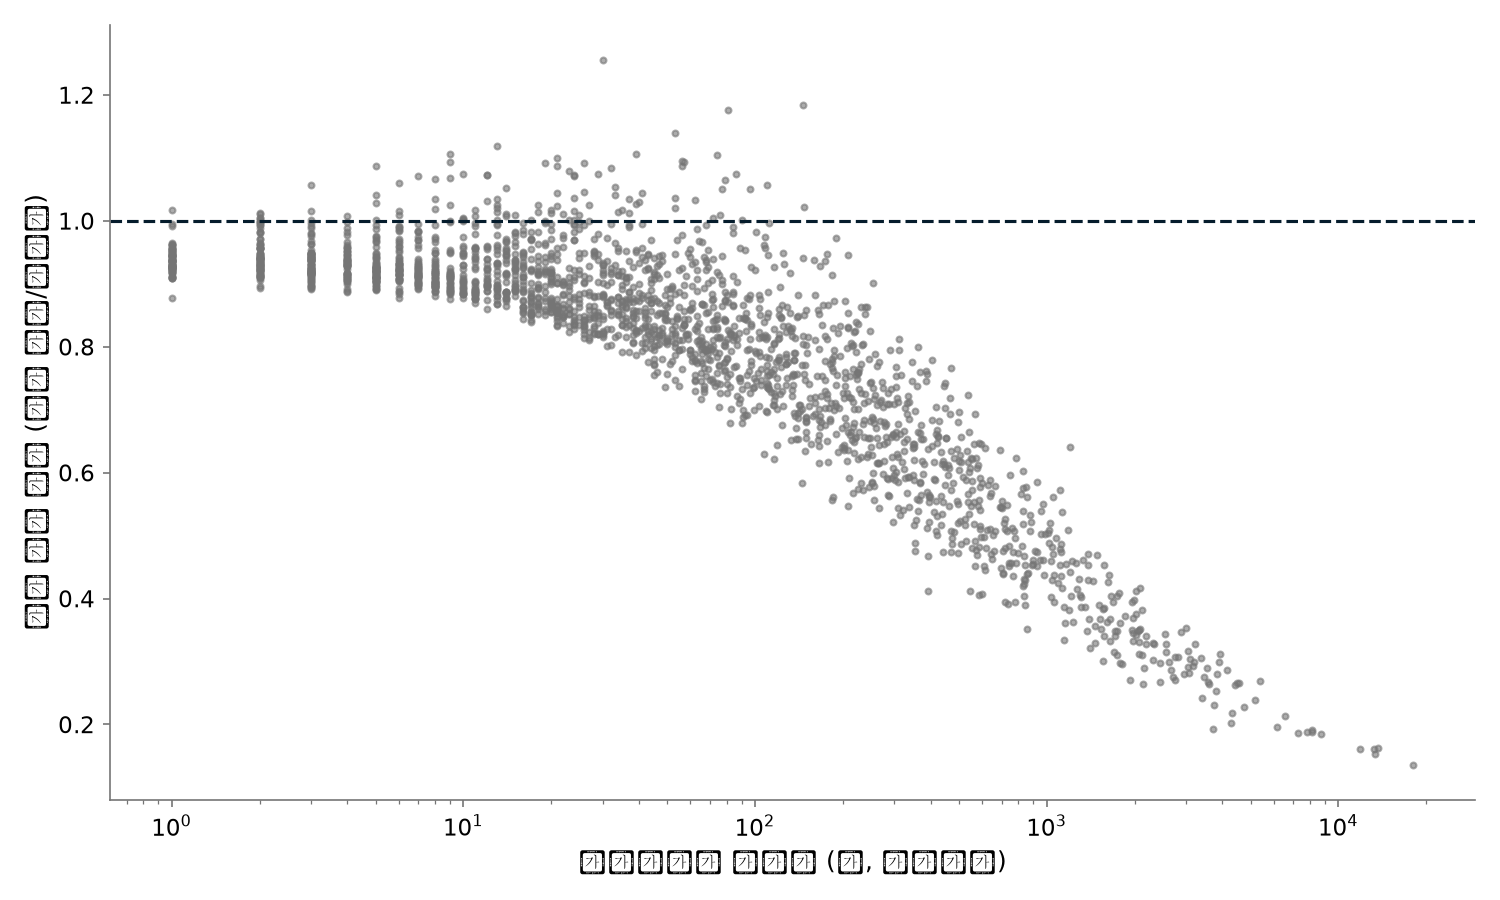

In [14]:
# 미션 3 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
아래 컬럼은 그대로 사용
N23: 세그먼트별 계약 수
K23: 세그먼트별 사고를 겪은 계약 수
RAW23: 무 풀링 값
P_POOL: 완전 풀링 값
J23: 총 세그먼트 수
I63: 계약 63건 사고 4건 세그먼트 번호
SE63: I63 세그먼트의 표준 오차
LO_D45, HI_D45: +-2 표준오차 구간의 아래 위 끝

1. I63의 부분 풀링 값: 단위 비율, 소수점 아래 4자리
2. I63의 95% 신용구간 길이: 단위 %p, 소수점 아래 2자리
3. 대조용 한행: 같은 세그먼트를 첫날의 표준오차 구간으로 계산한 구간 길이도 같은 단위로 출력
4. 그래프
점: 세그먼트 하나에 점 하나 2323개
상대 구간 길이: 세그먼트마다 그 세그먼트의 구간 길이를 I63의 부분 풀링 값으로 나눈 값
가로축 눈금: 로그 눈금, 가로선, 상대 구간 길이 1위치에 그림을 좌우로 가로지르는 선
가로축: 세그먼트의 계약수 (건, 로그눈금)
세로축: 상대 구간 길이 (구간 길이/추정값)

체인 4개 · 시드 49 로 고정하고, 반복 횟수와 워밍업 횟수는 미션 1 에 지정한 반복 1,000회와 워밍업 1,000회의 각각 2배로 지정
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm

logit_ppool = np.log(P_POOL / (1 - P_POOL))

with pm.Model() as model:
    mu = pm.Normal("mu", logit_ppool, 1.5)
    sigma = pm.HalfNormal("sigma", 1.0)
    z = pm.Normal("z", 0.0, 1.0, shape=J23)
    p = pm.Deterministic("p", pm.math.sigmoid(mu + sigma * z))
    pm.Binomial("obs", n=N23, p=p, observed=K23)
    idata = pm.sample(draws=2000, tune=2000, chains=4, random_seed=49, progressbar=False)

p_samples = idata.posterior["p"].values.reshape(-1, J23)

partial_63 = p_samples[:, I63].mean()
print(f"1) 계약 63건 세그먼트의 부분 풀링 값 (비율): {partial_63:.4f}")

ci_lo_63 = np.quantile(p_samples[:, I63], 0.025)
ci_hi_63 = np.quantile(p_samples[:, I63], 0.975)
ci_width_63 = (ci_hi_63 - ci_lo_63) * 100
print(f"2) I63의 95% 신용구간 길이 (%p): {ci_width_63:.2f}")

se_width = (HI_D45 - LO_D45) * 100
print(f"3) 대조용 — 첫날 ±2 표준오차 구간 길이 (%p): {se_width:.2f}")

lo_all = np.quantile(p_samples, 0.025, axis=0)
hi_all = np.quantile(p_samples, 0.975, axis=0)
rel_width = (hi_all - lo_all) / partial_63

fig, ax = plt.subplots(figsize=(FIG_W, 6))
ax.scatter(N23, rel_width, color=COL["회색"], s=8, alpha=0.6)
ax.axhline(1.0, color=COL["남색"], linestyle="--")
ax.set_xscale("log")
ax.set_xlabel("세그먼트의 계약수 (건, 로그눈금)")
ax.set_ylabel("상대 구간 길이 (구간 길이/추정값)")
plt.show()

In [15]:
# 과제 · 준비 — 읽고 실행만 합니다. 이 셀이 과제에 쓸 변수를 직접 만듭니다
if "N23" not in globals():                                       # 이 과제만 따로 열어도 이 셀부터 실행하면 됩니다
    from sklearn.datasets import fetch_openml                     # (미션 3 을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)        # 5일 내내 고정해 온 전처리 2개 규칙
    df["Exposure"] = df["Exposure"].clip(upper=1.0)
    df["사고겪음"] = (df["ClaimNb"] > 0).astype(int)
    SEGS2323 = (df.groupby(["Region", "VehBrand", "VehPower"], observed=True)
                   .agg(n=("IDpol", "size"), k=("사고겪음", "sum"))
                   .reset_index().sort_values(["Region", "VehBrand", "VehPower"])
                   .reset_index(drop=True))
    N23 = SEGS2323["n"].to_numpy(dtype=float)
    K23 = SEGS2323["k"].to_numpy(dtype=float)
    RAW23 = K23 / N23
    P_POOL = float(K23.sum() / N23.sum())
    J23 = int(len(N23))

SEG_NAME = (SEGS2323["Region"].astype(str) + " x " + SEGS2323["VehBrand"].astype(str)
             + " x " + SEGS2323["VehPower"].astype(str) + "등급").to_numpy()   # 쓸 변수 1 — 세그먼트 이름

# 미션 3 의 계층 이항을 시드 7 로 한 번 더 실행합니다. 표에 적을 2,323개 세그먼트의 값과 구간이
# 한 표본에서 함께 나와야 하는데, 미션 3 의 사후 표본은 학생이 붙인 이름이 제각각이라 이 셀이 가져다
# 쓸 수 없습니다. 시드가 미션 3 의 49 와 다르므로 미션 3 에서 본 값과 마지막 자릿수가 다릅니다
if "P_HIER" not in globals():                     # 한 번 얻어 두면 이 셀을 다시 실행해도 표집하지 않습니다
    with pm.Model():
        mu = pm.Normal("mu", -2.94, 1.0)
        tau = pm.HalfNormal("tau", 1.0)
        z = pm.Normal("z", 0.0, 1.0, shape=J23)
        theta = pm.Deterministic("theta", tau * z)
        pm.Binomial("obs", n=N23, p=pm.math.sigmoid(mu + theta), observed=K23)
        _posterior = pm.sample(draws=2000, tune=2000, chains=4, random_seed=7, progressbar=False)
    _log_vals = _posterior.posterior["mu"].values[..., None] + _posterior.posterior["theta"].values
    _seg_vals = (1 / (1 + np.exp(-_log_vals))).reshape(-1, J23)
    P_HIER = _seg_vals.mean(axis=0)                          # 쓸 변수 2 — 세그먼트별 부분 풀링 값 (비율)
    LO_HIER = np.percentile(_seg_vals, 2.5, axis=0)          # 쓸 변수 3 — 95% 신용구간의 아래끝
    HI_HIER = np.percentile(_seg_vals, 97.5, axis=0)         # 쓸 변수 4 — 95% 신용구간의 위끝
    _summary = az.summary(_posterior, var_names=["mu", "tau", "theta"])
    RHAT_MAX = float(_summary["r_hat"].max())               # 쓸 변수 5 — 이 표본의 가장 큰 R-hat
    ESS_MIN = float(_summary["ess_bulk"].min())             # 쓸 변수 6 — 이 표본에서 ess_bulk 열의 최솟값

# 사전분포 2벌의 공식으로 바로 구하는 해(closed-form) — 둘째 날의 그 계산이라 표집 없이 한 번의 계산으로 나옵니다
M_HAND, A_HAND = 102.0, 6.0        # 사람이 지정한 사전분포 — 가상 관측 102건에 사고 6건 (중심 6/102)
M_DATA = 300.0                     # 데이터로 추정한 사전 강도 — 세그먼트 간 표준편차에서 환산한 수
MAP_HAND = (K23 + A_HAND - 1) / (N23 + M_HAND - 2)                    # 쓸 변수 7 — 사람이 지정한 사전분포의 값
MAP_DATA = (K23 + M_DATA * P_POOL - 1) / (N23 + M_DATA - 2)           # 쓸 변수 8 — 데이터로 추정한 사전분포의 값

_i63 = int(np.flatnonzero((N23 == 63) & (K23 == 4))[0])
print(f"세그먼트 {J23:,} 개 · 계약 수 중앙 {np.median(N23):,.0f} 건 · 사고를 한 건도 겪지 않은 세그먼트 "
      f"{int((K23 == 0).sum()):,} 개 ({(K23 == 0).mean() * 100:.1f}%) · 계약 1,000건 이상 "
      f"{int((N23 >= 1000).sum()):,} 개")
print(f"여기서 다루는 값은 사고 경험률(비율) 하나입니다 — 완전 풀링 값 {P_POOL:.6f}")
print(f"계층 사후 진단 — 가장 큰 R-hat {RHAT_MAX:.4f} (기준값 1.01) · 가장 작은 유효표본수 "
      f"{ESS_MIN:,.0f} 개 (기준값 400)")
print(f"계약 63건·사고 4건 세그먼트 — 무 풀링 {RAW23[_i63]:.6f} · 사람이 지정한 사전분포 {MAP_HAND[_i63]:.6f}"
      f" · 데이터로 추정한 사전분포 {MAP_DATA[_i63]:.6f} · 부분 풀링 {P_HIER[_i63]:.6f}"
      f" [{LO_HIER[_i63]:.4f}, {HI_HIER[_i63]:.4f}]")
print("쓸 수 있는 이름 : SEG_NAME (세그먼트 이름) · N23 (세그먼트별 계약 수, 건) · K23 (사고를 겪은 계약 수, 건)"
      " · RAW23 (무 풀링, 비율) · P_POOL (계약 전체, 비율) · J23 (세그먼트 수)"
      " · P_HIER (부분 풀링 값, 비율) · LO_HIER · HI_HIER (95% 신용구간의 두 끝)"
      " · MAP_HAND · MAP_DATA (사전분포 2벌이 낸 값, 비율) · M_HAND · M_DATA (그 사전 강도, 건)"
      " · RHAT_MAX · ESS_MIN (이 표본의 진단값 2개)")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, tau, z]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 57 seconds.


세그먼트 2,323 개 · 계약 수 중앙 41 건 · 사고를 한 건도 겪지 않은 세그먼트 756 개 (32.5%) · 계약 1,000건 이상 156 개
여기서 다루는 값은 사고 경험률(비율) 하나입니다 — 완전 풀링 값 0.050235
계층 사후 진단 — 가장 큰 R-hat 1.0057 (기준값 1.01) · 가장 작은 유효표본수 2,044 개 (기준값 400)
계약 63건·사고 4건 세그먼트 — 무 풀링 0.063492 · 사람이 지정한 사전분포 0.055215 · 데이터로 추정한 사전분포 0.050057 · 부분 풀링 0.050465 [0.0306, 0.0772]
쓸 수 있는 이름 : SEG_NAME (세그먼트 이름) · N23 (세그먼트별 계약 수, 건) · K23 (사고를 겪은 계약 수, 건) · RAW23 (무 풀링, 비율) · P_POOL (계약 전체, 비율) · J23 (세그먼트 수) · P_HIER (부분 풀링 값, 비율) · LO_HIER · HI_HIER (95% 신용구간의 두 끝) · MAP_HAND · MAP_DATA (사전분포 2벌이 낸 값, 비율) · M_HAND · M_DATA (그 사전 강도, 건) · RHAT_MAX · ESS_MIN (이 표본의 진단값 2개)


1) 저장한 표의 컬럼 수 (개): 8
2) 전체 계약의 사고 경험률 (비율): 0.050235
4) 자동승인 세그먼트 수 (개): 2118개
4) 사람심사 세그먼트 수 (개): 205개


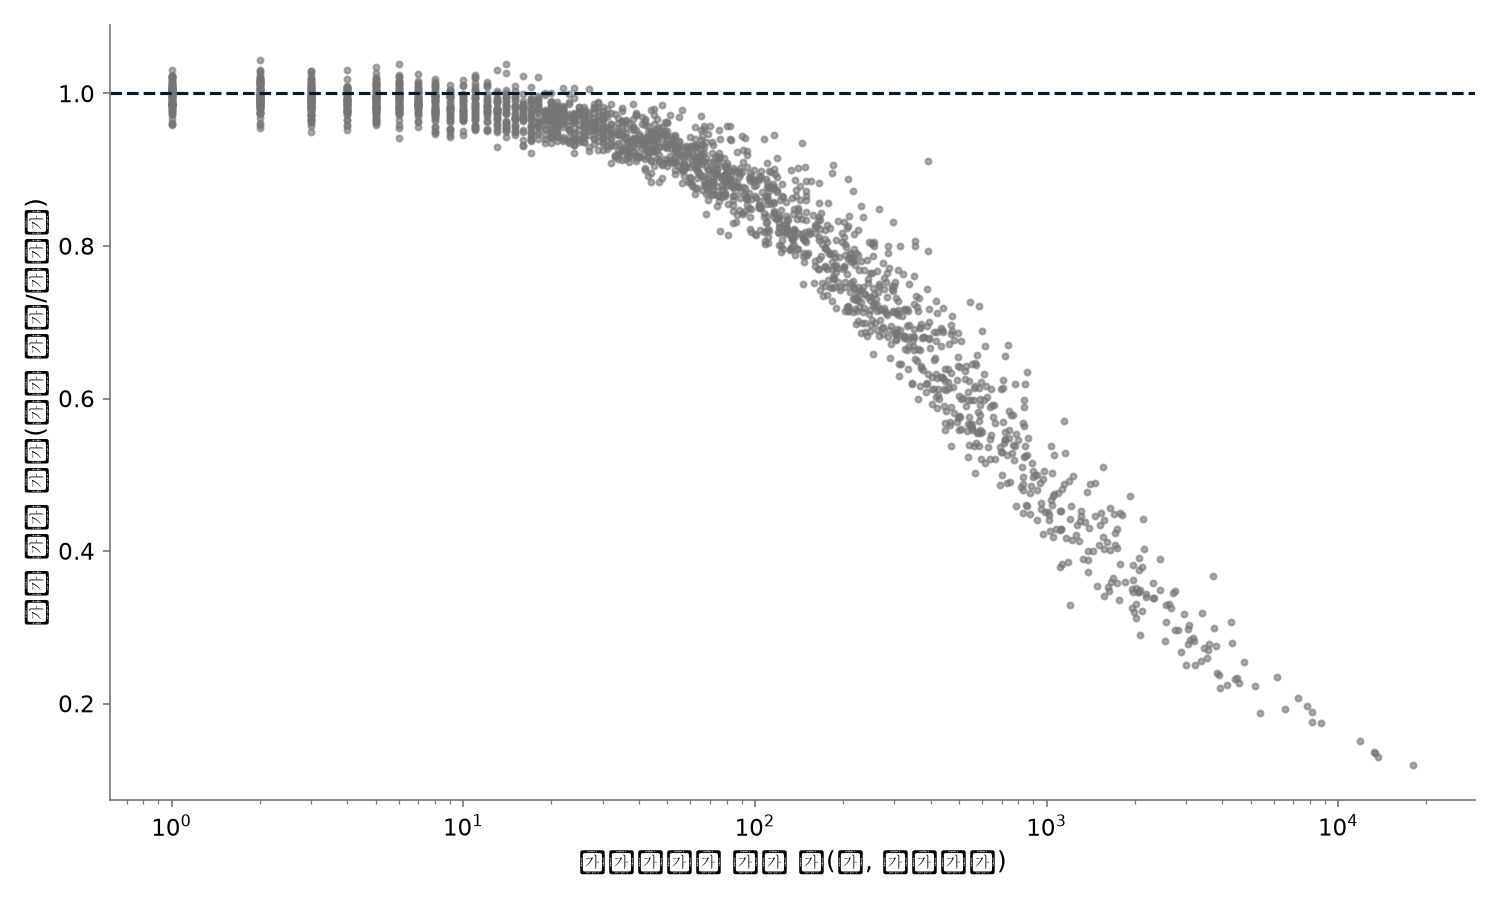

In [17]:
# 과제 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
아래 컬럼 그대로 사용(필수)
SEG_NAME: 세그먼트 이름
N23: 세그먼트별 계약 수
K23: 세그먼트별 사고를 겪은 계약 수
RAW23: 세그먼트별 무 풀링 값
P_POOL: 완전 풀링 값
P_HIER: 세그먼트별 부분 풀링 값
LO_HIER, HI_HIER: 95% 신용구간 아래 위의 끝
MAP_HAND, MAP_DATA: 사선분포 2벌이 낸 사후분포의 최빈값
RHAT_MAX, ESS_MIN: 진단값 2개

1. 지정한 표의 컬럼 수 : 단위 개, 정수(저장한 파일을 다시 읽어 계산한 열 개수)
2. 전체 계약의 사고 경험률: 단위 비율, 소수점아래 6자리(K23의 합을 N23합으로 나눈 값)
3. 저장할 파일 한장: 요율표_세그먼트별요율_v2.csv
4. 대조용 2행: 판정 열의 '자동승일' 세그먼트 수와 '사람심사' 세그먼트 수를 각각 한 행으로 출력
5. 그래프
점: 세그먼트 하나에 점 하나(스코프 결정에서 고른 세그먼트 수와 동일)
가로선: 내가 기준 결정에서 고른 값 위치에 좌우 가로지르는 선 하나
가로축 이름: 세그먼트의 계약 수(건, 로그눈금)
세로축 이름: 상대 구간 길이(구간 길이/추정값)

스코프: 	지역 × 브랜드 × 차량 출력 등급 2,323개 세그먼트
방법: 계층 모형의 부분 풀링 값(MAP_DATA)
판정 기준값: 상대 구간 길이 1.0
"""
# --- 여기부터 AI 코드 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REL_WIDTH = (HI_HIER - LO_HIER) / MAP_DATA
JUDGE = np.where(REL_WIDTH < 1.0, "자동승인", "사람심사")

RATE_TABLE = pd.DataFrame({
    "SEG_NAME": SEG_NAME,
    "N23": N23,
    "K23": K23,
    "RAW23": RAW23,
    "MAP_DATA": MAP_DATA,
    "LO_HIER": LO_HIER,
    "HI_HIER": HI_HIER,
    "판정": JUDGE,
})

RATE_TABLE.to_csv("요율표_세그먼트별요율_v2.csv", index=False)

reloaded = pd.read_csv("요율표_세그먼트별요율_v2.csv")
print(f"1) 저장한 표의 컬럼 수 (개): {reloaded.shape[1]}")

overall_rate = K23.sum() / N23.sum()
print(f"2) 전체 계약의 사고 경험률 (비율): {overall_rate:.6f}")

n_auto = int((RATE_TABLE["판정"] == "자동승인").sum())
n_human = int((RATE_TABLE["판정"] == "사람심사").sum())
print(f"4) 자동승인 세그먼트 수 (개): {n_auto}개")
print(f"4) 사람심사 세그먼트 수 (개): {n_human}개")

fig, ax = plt.subplots(figsize=(FIG_W, 6))
ax.scatter(N23, REL_WIDTH, color=COL["회색"], s=8, alpha=0.6)
ax.axhline(1.0, color=COL["남색"], linestyle="--")
ax.set_xscale("log")
ax.set_xlabel("세그먼트의 계약 수(건, 로그눈금)")
ax.set_ylabel("상대 구간 길이(구간 길이/추정값)")
plt.show()

In [18]:
import numpy as np

diff = MAP_DATA - MAP_HAND
diff_pp = diff * 100  # %p 단위

print(f"평균 차이 (%p): {diff_pp.mean():.4f}")
print(f"최대 절대 차이 (%p): {np.abs(diff_pp).max():.4f}")
print(f"차이 0.5%p 넘는 세그먼트 수 (개): {(np.abs(diff_pp) > 0.5).sum()}")
print(f"차이가 큰 세그먼트일수록 계약 수(N23) 분포:", N23[np.abs(diff_pp) > 0.5].mean())

평균 차이 (%p): -0.1636
최대 절대 차이 (%p): 2.8068
차이 0.5%p 넘는 세그먼트 수 (개): 558
차이가 큰 세그먼트일수록 계약 수(N23) 분포: 90.09677419354838


사전 강도 102건과 약 300건 가운데 무엇을 적는가 — 팀에서 3문장으로 답하기
재무팀이 마지막으로 질문합니다. "관측이 적은 세그먼트에 적을 값을 정하는 그 사전 강도는 둘째 날에 우리가 102건으로 정했습니다. 오늘은 데이터로 추정하니 약 300건이라고 들었습니다. 요율표에는 어느 쪽을 적습니까?" 오늘 만든 표만으로 답해 보세요. (가) 두 값이 실제로 얼마나 다른지 수로, (나) 데이터로 추정한 사전 강도를 쓸 때 다음 분기에 무엇이 달라질 수 있는지, (다) 그래도 그 표를 이사회에 제출할 수 있게 하려면 표에 무엇을 함께 적어야 하는지를 3문장으로 적어 보세요.

(가) 두 값이 실제로 얼마나 다른지 수로
평균 차이 (%p): -0.1636
최대 절대 차이 (%p): 2.8068
차이 0.5%p 넘는 세그먼트 수 (개): 558
차이가 큰 세그먼트일수록 계약 수(N23) 분포: 90.09677419354838

(나) 데이터로 추정한 사전 강도를 쓸 때 다음 분기에 무엇이 달라질 수 있는지
사전 강도를 102건에서 약 300건으로 올리면 완전 풀링 값 쪽으로 수축이 더 세짐.
관측이 적은 세그먼트일수록 그 세그먼트만의 실제 위험 신호가 더 많이 뭉개지고, 다음 분기에 그 세그먼트에서 손해율이 실제로 튀는 방향과 다르게 움직이면 요율 반영이 늦어져 손해율 오차가 한 분기 더 누적될 수 있음.
반대로 노이즈였을 경우엔 더 안정적인 요율을 유지하는 이점 — 즉 안정성과 반응 속도의 트레이드오프.

(다) 그래도 그 표를 이사회에 제출할 수 있게 하려면 표에 무엇을 함께 적어야 하는지를 3문장
사용한 사전 강도 값(102 또는 약 300)과 그 근거(사람이 정함 vs 데이터로 추정)
두 사전분포 간 최대/평균 차이
각 세그먼트의 R-hat·유효표본수(신뢰 가능 여부)
판정 기준값(상대 구간 길이 몇 이상이면 사람심사인지)과 그 기준으로 갈린 자동승인/사람심사 세그먼트 수

